# Logistic Regression - Fraud anamonly classification

*Author:*: Mohammed Musaddiq Vavartar

*Date:* May 2026

*Goal:* Training and comparing two Logistic Regression models for 4-class fraud risk classification.

## Models
- **Model [1]:** Standard Logistic Regression with `class_weight='balanced'`
- **Model [2]:** SMOTE oversampling + Logistic Regression

## 4 Classes
| Class             | Label    | Meaning |
| :---------------- | :------: | :---: |
| 0      |   TT   | Legit, Normal  |
| 1           |   TF  | Legit, Suspicious |
| 2    |  FT   | Fraud, With Low Impact |
| 3 |  FF  | Fraud, With High Impact |




## 1. Imports 
All necessary libraries loaded to process the data, build models, generate visualizations, and track experiments.

In [73]:
# default libs
import os
# beautify
import warnings
warnings.filterwarnings('ignore')

# for data process
import numpy as np
import pandas as pd

# plots, bar and confusion mtrx
import matplotlib.pyplot as plt
import seaborn as sns

# Sktlearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

# due to imbalance, SMOTE to get synthetic data
from imblearn.over_sampling import SMOTE

# to save to trained model -> /models
import joblib

# to track 
import mlflow
import mlflow.sklearn

print("All imports done!")

All imports done!


In [74]:
# loading data
DATA_PATH = '../data/processed/'

# std preprocessing 
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
y_train = pd.read_csv(DATA_PATH + 'y_train.csv').squeeze()
X_test  = pd.read_csv(DATA_PATH + 'X_test.csv')
# squeeze to change from df to series
y_test  = pd.read_csv(DATA_PATH + 'y_test.csv').squeeze()

print(" Data loaded successfully")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_test  : {y_test.shape}")

 Data loaded successfully
   X_train : (80000, 42)
   X_test  : (20000, 42)
   y_train : (80000,)
   y_test  : (20000,)


## 2. Data loading and Cleaning
Loading the train/test splits after preprocessing using data stored via DVC. Cleaning up column names, cleaning dirty numbers, converting boolean strings into numbers, and then to removing unnecessary time information.

In [75]:
#  same data path , just clear data loading [redundant and can be avoided]
DATA_PATH = '../data/processed/'

# for clarity -> loading the data again [redundant and can be avoided]
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
X_test  = pd.read_csv(DATA_PATH + 'X_test.csv')
# squeezing to get series instead of df
y_train = pd.read_csv(DATA_PATH + 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_PATH + 'y_test.csv').squeeze()


# no.1 if any column names have spcaes or unwanted characters, then 
# stripping 
X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()
print(" Column names cleaned")

# dirty values in numeric cols 
# basically non numeric values are big pain in training : so non numeric to numeric & Nan to median
columns_num_prep = [
    'merchant_risk_30_day', 'merchant_risk_7_day',
    'trans_time_is_night', 'trans_date_is_weekend',
    'customer_num_trans_1_day', 'amt', 'avg_amt_per_customer'
]
for i in columns_num_prep:
    # lesson look up to learn noted in onedrive/mlops/learn.docx
    # coerce means coercion -> convering one data type to another 
    # here it is converting to numeric and if it fails, it will be NaN -> then we can fillna with median
    X_train[i] = pd.to_numeric(X_train[i], errors='coerce')
    X_test[i]  = pd.to_numeric(X_test[i],  errors='coerce')
    median_v   = X_train[i].median()
    # filling NaA with median 
    X_train[i] = X_train[i].fillna(median_v)
    X_test[i]  = X_test[i].fillna(median_v)
print(" Numeric columns cleaned")

# just not needed for me in LR
drop1 = ['dob', 'trans_date', 'trans_time']
X_train = X_train.drop(columns=drop1)
X_test  = X_test.drop(columns=drop1)
print(" Dropped date columns")

# Stripping space and map cols to 1/0
columns_boolean_map = [
    'gender_M',
    'category_food_dining', 'category_gas_transport',
    'category_grocery_net', 'category_grocery_pos',
    'category_health_fitness', 'category_home',
    'category_kids_pets', 'category_misc_net',
    'category_misc_pos', 'category_personal_care',
    'category_shopping_net', 'category_shopping_pos',
    'category_travel'
]

# 
for i in columns_boolean_map:
    # Strip spaces first THEN map to 1/0
    X_train[i] = X_train[i].str.strip().map({'True': 1, 'False': 0})
    X_test[i]  = X_test[i].str.strip().map({'True': 1, 'False': 0})
print(" Boolean columns handled ")

# verifying all before moving on 
# isna().sum().sum() gived all NaN values in df 
print(f"\nNaN values in X_train: {X_train.isna().sum().sum()}")
print(f"NaN values in X_test:  {X_test.isna().sum().sum()}")
# non numerics as objects are checked 
# our dataset doesnt have it or are already handled 
print(f"The non-numeric columns are:   {X_train.select_dtypes(exclude='number').columns.tolist()}")

# just info 
print(f"\nX_train shape are: {X_train.shape}")
print(f"X_test shape are:  {X_test.shape}")

 Column names cleaned
 Numeric columns cleaned
 Dropped date columns
 Boolean columns handled 

NaN values in X_train: 0
NaN values in X_test:  0
The non-numeric columns are:   []

X_train shape are: (80000, 39)
X_test shape are:  (20000, 39)


In [76]:
# checking the ranges of these columns as they are important for my fraud anamoly classification
key_cols_checking = [
    'amt',
    'avg_amt_per_customer',
    # merchant risk means how risky the mercant is based on past 30 and 7 days transactions 
    'merchant_risk_30_day',
    'merchant_risk_7_day',
    # fraud over night IMPORTANT 
    'trans_time_is_night',
    'trans_date_is_weekend',
    # to see unusual number of transactions 
    'customer_num_trans_1_day'
]

# stats to see the range 
print(X_train[key_cols_checking].describe().round(2))

# beautify 
print("\nFraud vs Legit  average transaction amount:")
combined = X_train.copy()
combined['is_fraud'] = y_train.values
#sats rounded to 2 decimals
print(combined.groupby('is_fraud')['amt'].describe().round(2))

            amt  avg_amt_per_customer  merchant_risk_30_day  \
count  80000.00              80000.00              80000.00   
mean      72.65                 72.95                 16.12   
std      157.52                 53.79                  4.81   
min        1.00                  1.03                  0.00   
25%        9.26                 45.20                 13.00   
50%       45.23                 61.90                 17.00   
75%       82.35                 86.37                 20.00   
max    14275.64               1166.40                 23.00   

       merchant_risk_7_day  trans_time_is_night  trans_date_is_weekend  \
count             80000.00             80000.00               80000.00   
mean                  9.26                 0.29                   0.40   
std                   3.83                 0.45                   0.49   
min                   0.00                 0.00                   0.00   
25%                   6.00                 0.00               

## 3. Building 4 class risk labels
Now we are using the binary variable `is_fraud` but,  to a 4-class fraud risk system using behavior and merchant risk attributes.

#### Amount threshold for fraud 
#### Using $264 (25th percentile of fraud) instead of $100 which is standard amount to see

• FT = is_fraud=1 AND amt < 264    [it gives us the bottom 25% of fraud = low impact]

• FF = is_fraud=1 AND amt >= 264   [now this gives us the top 75% of fraud = high impact, so above is better split]

#### Likewise for threshold,
##### Amount threshold for legit suspicious
##### Legit mean = $67, so 3x = $200 is a good threshold

logic:

**TF** = `is_fraud = 0` AND (
     *from the dataset columns - to get better understanding of how the classes are being distributed*
- `amt > 200`  
- `trans_time_is_night == 1`  *(night transaction)*
- `merchant_risk_30_day >= 20`  *(top 25% risky merchant)*
- `customer_num_trans_1_day >= 5`  *(burst of transactions)*
)


**TT** = everything else legit [all gucci]

In [77]:
#  multi class labels 

# 4 classes will give beter understanding that just fraud vs legit
# most importantly the risk is understood 
def create_4class_labels(X, y):
    """
    Createing 4-class fraud risk labels.

    # 0-3 is fine as indices start from 0 and balanced wont prioritize one class over another
    Classes:
        0 - TT: Fully Legit, Completely Normal      (not fraud, nothing suspicious)
        1 - TF: Legit, Little Suspicious based on factors ->  (not fraud, but warning signals)
        2 - FT: Fraud, Low Risk and Less Harmful for Customers  main factor to decide -> (fraud at low risk merchant  < 17)
        3 - FF: Fraud, High Risk and Must be Seen Into  (fraud at high risk merchant >= 17 : 17 gave a balanced split)
    
    note ; FT/FF split by merchant_risk_30_day (48/52 split)
    amount gives a split like 25/75 imbalanced 
    """

    # key features for my rules
    amt       = X['amt']
    cus_avg_amt   = X['avg_amt_per_customer']
    risk_lvl30   = X['merchant_risk_30_day']
    risk__lvl7    = X['merchant_risk_7_day']
    is_night_not  = X['trans_time_is_night']
    is_wknd_not   = X['trans_date_is_weekend']
    day_total_trans = X['customer_num_trans_1_day']
    is_fraud  = y.values


    #  TF: most colums involved as Legit day to day transactions can still has some suspicious behavior to be aware 
    suspicious = (
        (risk_lvl30 >= 21)          |   # risky merchant 
        (amt > cus_avg_amt * 2)      |   # twice the  usual average
        ((is_night_not == 1) & (amt > 200))  # night & high amount unusual things 
    )

    #  for FT vs FF using the note: splitting ny merchant risk 
    merch_high_risk30 = (risk_lvl30 >= 17)   # above median merchant risk

    # just std label bulding 
    labels = pd.Series(0, index=X.index)

    # different levels of SUS for my multi class

    #  low as it is not a fraud but some thing fishy 
    labels[(is_fraud == 0) & suspicious]            = 1

    # moderate as marked as fraud but merchant is not that risky
    labels[(is_fraud == 1) & ~merch_high_risk30]   = 2

    # high and need to be seen into as marked as fraud and merchant is risky
    labels[(is_fraud == 1) & merch_high_risk30]    = 3

    return labels


# beautify
print("The 4 class labels...")

# using the func above to make new labels
y_train_4 = create_4class_labels(X_train, y_train)
y_test_4  = create_4class_labels(X_test,  y_test)

# beautify
print(" Done!")
print("\n Train label distribution ")

# getting counts and  % for each of my 4 class
counts = y_train_4.value_counts().sort_index()
#multiply to get  % 
props  = y_train_4.value_counts(normalize=True).sort_index().mul(100).round(2)

# why 0 - 3  and not just 1 - 4 ?
# as indices start from 0 and better for mapping to label names 
label_names = {
    0: 'TT-Legit-Normal',
    1: 'TF-Legit-Suspicious',
    2: 'FT-Fraud-LowRisk',
    3: 'FF-Fraud-HighRisk'
}

# printing info 
for i in range(4):
    # percentage converion to easy reading 
    print(f"  Class {i} ({label_names[i]:22s}): "
          f"{counts[i]:6d} rows  ({props[i]:.2f}%)")

The 4 class labels...
 Done!

 Train label distribution 
  Class 0 (TT-Legit-Normal       ):  53934 rows  (67.42%)
  Class 1 (TF-Legit-Suspicious   ):  25179 rows  (31.47%)
  Class 2 (FT-Fraud-LowRisk      ):    428 rows  (0.53%)
  Class 3 (FF-Fraud-HighRisk     ):    459 rows  (0.57%)


## 5. Label distribution visualization
Visualize the distribution of the class within all four risk categories to know the class imbalance before to training.

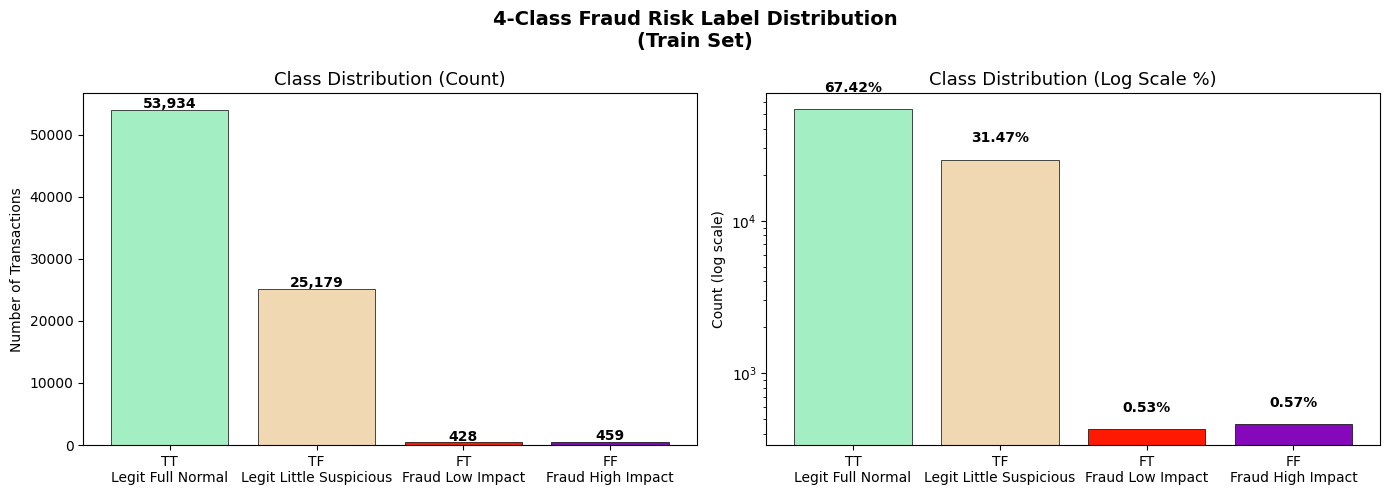

 Chart saved!


In [78]:
# overall box size for both the charts 
fig_m1, axes_m2 = plt.subplots(1, 2, figsize=(14, 5))

# asthetic less are dark in color and more are light in color
colors = ["#a4eec3", "#f0d8b2", "#ff1900", "#8508ba"]
labels = ['TT\nLegit Full Normal', 'TF\nLegit Little Suspicious', 'FT\nFraud Low Impact', 'FF\nFraud High Impact']

# lefty 

# bar chart showing the actual count for each class 
axes_m2[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes_m2[0].set_title('Class Distribution (Count)', fontsize=13)
axes_m2[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes_m2[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10, fontweight='bold')


# righty

# % of each class : imbalance can be seen
axes_m2[1].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes_m2[1].set_yscale('log')          
axes_m2[1].set_title('Class Distribution (Log Scale %)', fontsize=13)
axes_m2[1].set_ylabel('Count (log scale)')

# displaying the % of each labels on the top 
for i, (v, p) in enumerate(zip(counts.values, props.values)):
    axes_m2[1].text(i, v * 1.3, f'{p}%', ha='center', fontsize=10, fontweight='bold')

# tt
plt.suptitle('4-Class Fraud Risk Label Distribution\n(Train Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()

# all aboard next stop to the  /reports/figures/label_distribution.png
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved!")

In [79]:
# helped me debug and checking all guccie before training 
print(" Again Data Ready Check ")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

# if this shows 0 means cell 2 worked !
print(f" Confirming original data has not been affected : NaN in train  : {X_train.isna().sum().sum()}")
print(f" Confirming original data has not been affected : NaN in test   : {X_test.isna().sum().sum()}")
print(f"y_train_4 classes: {sorted(y_train_4.unique())}")
print(f"y_test_4  classes: {sorted(y_test_4.unique())}")

# isna().sum().sum() will give full count of NaN in df
print("\n DO training next! " if X_train.isna().sum().sum() == 0 else " Still has issues")

 Again Data Ready Check 
X_train shape : (80000, 39)
X_test shape  : (20000, 39)
 Confirming original data has not been affected : NaN in train  : 0
 Confirming original data has not been affected : NaN in test   : 0
y_train_4 classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
y_test_4  classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

 DO training next! 


## 6. feature enginnering
Introducing 5 new engineered variables based on domain knowledge to enhance separation between classes, especially when distinguishing TF and FF.


In [80]:
# As the imbalance is big,  trying out some ratio based feature so that the model learns better than nothing 

def add_features(X):
    """
    Adding features to improve class for  separation.
    
    note:  THe TF has amt/avg ratio approx 1.74 vs TT  approx 0.61
                            &
           The FF with high merchant_risk AND high amt ratio
    """

    # my train and test are copied to not change the OG df
    X = X.copy()
    
    # no.1 
    # example: if a cusomter spends 100 usually but suddenly spends 500 then: 500/100 = 5 which is high and can be a fraud 
    # real life scenario: Bank might notify you of the sum amt and say did you make it. 
    X['amt_ratio'] = X['amt'] / (X['avg_amt_per_customer'] + 1)
    
    # no.2
    # we did split labels based on merchant risk but,  combining both can give better risk signals
    X['combined_risk'] = (
        X['merchant_risk_30_day'] * 0.6 +  X['merchant_risk_7_day']  * 0.4
    )
    
    # no.3 
    # the above 2 features are combined and related to amount to get risk score 
    X['amt_risk_score'] = X['amt_ratio'] * X['merchant_risk_30_day']
    
    #no.4
    # we did ratio of the customer's AVG but, the difference in amount spend directly can be better for the model to learn than just the ratio
    X['is_high_spend'] = (X['amt'] > X['avg_amt_per_customer'] * 1.5).astype(int)
    
    #no.5 classic
    # night time and insane amount is high chance of fraud
    X['night_high_amt'] = (
        (X['trans_time_is_night'] == 1) & 
        (X['amt'] > 100)
    ).astype(int)

    return X

# using the above func on train and test 
X_tr_feature_eg = add_features(X_train)
X_tst_feature_eg  = add_features(X_test)

# beautify
print(" Added 5 features for better learning & separation based on EDA ")
print(f"New shape: {X_tr_feature_eg.shape}  (was {X_train.shape})")

# stats of all 5 new features 
print(f"\nNew features added:")
key_columns_feature = ['amt_ratio', 'combined_risk', 'amt_risk_score', 
            'is_high_spend', 'night_high_amt']
print(X_tr_feature_eg[key_columns_feature].describe().round(2))

 Added 5 features for better learning & separation based on EDA 
New shape: (80000, 44)  (was (80000, 39))

New features added:
       amt_ratio  combined_risk  amt_risk_score  is_high_spend  night_high_amt
count   80000.00       80000.00        80000.00       80000.00        80000.00
mean        0.98          13.37           15.80           0.22            0.05
std         1.20           3.77           20.70           0.42            0.22
min         0.00           0.00            0.00           0.00            0.00
25%         0.18          11.00            2.66           0.00            0.00
50%         0.66          14.00            9.59           0.00            0.00
75%         1.36          16.20           21.54           0.00            0.00
max        30.73          19.80          706.77           1.00            1.00


## 7. Model [1]: Logistic regression with balanced weigths
Making a Logistic Regression model as a baseline classifier with `class_weight='balanced'`. Measuring reliability through 5-Fold Stratified Cross-Validation.

In [81]:
#  First model [1] logistic regression 
#  using balanced class weight due to imbalaance in labels 
# fruad will get than legit to get more attention and better learning 
 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time

# beautify 
print("=" * 55)
print("  Model 1: Logistic Regression (class_weight=balanced)")
print("=" * 55)


# model has max_iter to 1000 because of convergence, as the data is large and new features are added, so iterations are high so that the model learns better. 
# random_state for reproducibility 
# n_jobs -1 use all cores - RIP my mac 
model_lr_1 = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

#  CV with 5 folds, same random state for reproducibility[grade imp]
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#beautify
print("\nRunning 5-Fold Cross Validation...")

# time calculation
start_t = time.time()

# cv score to evaluate the model using f1 weighted 
cv_scores_m1 = cross_val_score(
    model_lr_1, X_tr_feature_eg, y_train_4,
    cv      = cross_val,
    scoring = 'f1_weighted',
    n_jobs  = -1
)

end_t = time.time() - start_t

#printing info
print(f"\n Done in {end_t:.1f} seconds!")
print("\n CV Results ")
# each fold score 
for i, got_score in enumerate(cv_scores_m1):
    print(f"   Fold {i+1}: {got_score:.4f}")
    # mean and std dev
print(f"\n   Mean F1 : {cv_scores_m1.mean():.4f}")
print(f"   Std Dev : {cv_scores_m1.std():.4f}")

  Model 1: Logistic Regression (class_weight=balanced)

Running 5-Fold Cross Validation...

 Done in 29.9 seconds!

 CV Results 
   Fold 1: 0.6430
   Fold 2: 0.6444
   Fold 3: 0.6432
   Fold 4: 0.5733
   Fold 5: 0.6287

   Mean F1 : 0.6265
   Std Dev : 0.0272


## 8 Model 1 Evaluation 
Training Model 1 on the whole training dataset and testing on the reserved test dataset. Calculating precision, recall, and F1 score for each class along with plotting the confusion matrix.

Training Model 1 on full training set...
 Done!

 Model 1 Test Set Results 
                     precision    recall  f1-score   support

    TT-Legit-Normal       0.76      0.80      0.78     13395
TF-Legit-Suspicious       0.48      0.36      0.41      6383
       FT-Fraud-Low       0.10      0.41      0.16       109
      FF-Fraud-High       0.05      0.33      0.08       113

           accuracy                           0.65     20000
          macro avg       0.35      0.47      0.36     20000
       weighted avg       0.67      0.65      0.66     20000



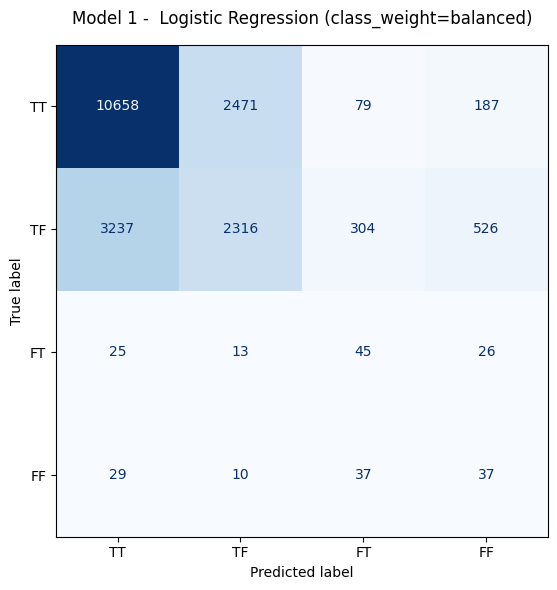

 Confusion matrix saved to /reports/..!


In [82]:
# Training model on the 100k rows data set  
# Future: train on 1 million rows dataset 

# beautify
print("Training Model 1 on full training set...")
model_lr_1.fit(X_tr_feature_eg, y_train_4)
print(" Done!")

# test 
y_pred_m1 = model_lr_1.predict(X_tst_feature_eg)

# as for anamoly classification then the confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# beautify
print("\n Model 1 Test Set Results ")

# classification report based on 4 class
print(classification_report(
    y_test_4, y_pred_m1,
    target_names = [
        'TT-Legit-Normal',
        'TF-Legit-Suspicious',
        'FT-Fraud-Low',
        'FF-Fraud-High'
    ]
))

#  Confusion Matrix 
fig_m1, ax_m1 = plt.subplots(figsize=(8, 6))
cm1 = confusion_matrix(y_test_4, y_pred_m1)

# displaying the confusion matrix
cm_disp = ConfusionMatrixDisplay(
    confusion_matrix = cm1,
    display_labels   = ['TT', 'TF', 'FT', 'FF']
)
cm_disp.plot(ax=ax_m1, cmap='Blues', colorbar=False, values_format='d')
ax_m1.set_title('Model 1 -  Logistic Regression (class_weight=balanced)',
             fontsize=12, pad=15)
plt.tight_layout()

# throw it to /reports/figures/m1_confusion_matrix
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/m1_confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion matrix saved to /reports/..!")

## 9. Model [2]: Smote over sampling
Use of SMOTE (Synthetic Minority Oversampling Technique) to create physical balance in all 4 classes before training. SMOTE generates synthetic data points for minority classes using interpolation techniques.

In [83]:
# Second model[2] : LR + SMOTE 
from imblearn.over_sampling import SMOTE

# beautify
print("=" * 55)
print("  Model 2: SMOTE + Logistic Regression")
print("=" * 55)


# we do SMOTE on train only as test must not be seen ;) 
print("\nApplying SMOTE to balance classes...")

# showing the imbalance to compare 
print(f"Before SMOTE: {y_train_4.value_counts().sort_index().to_dict()}")

# smote with default k_neigh = 5 & same random state 
smote_k = SMOTE(random_state=42, k_neighbors=5)

# time calc
start_t = time.time()
X_train_smote_app, y_train_smote_app = smote_k.fit_resample(X_tr_feature_eg, y_train_4)
end_t = time.time() - start_t

# beautify
print(f" SMOTE done in {end_t:.1f} seconds!")
print(f"\nAfter SMOTE:")

# Again! no. of rows and % of each class on fraud anamoly classification 
count_smote_affected_rows = pd.Series(y_train_smote_app).value_counts().sort_index()
for i, count in count_smote_affected_rows.items():
    print(f"  Class {i} ({label_names[i]:22s}): {count:6d} rows")

# Lr using for SMOTE 
# same max_iter, random_state and n_jobs. Hence difference is training on SMOTE data vs OG data 
model_2_smote_lr = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

# CV 5 FOLDS!!!!

#beautify
print("\nRunning 5-Fold Cross Validation...")

# time calc
start_t = time.time()

# cv score for evaluation 
cv_scores_m2 = cross_val_score(
    model_2_smote_lr, X_train_smote_app, y_train_smote_app,
    cv      = cross_val,
    scoring = 'f1_weighted',
    n_jobs  = -1
)
end_t = time.time() - start_t

# print info 
print(f" Done in {end_t:.1f} seconds!")
print("\n Cross validation  below: [SMOTE]")
# each folds score
for i, got_score in enumerate(cv_scores_m2):
    print(f"   Fold {i+1}: {got_score:.4f}")
    # mean and std dev 
print(f"\n   Mean F1 : {cv_scores_m2.mean():.4f}")
print(f"   Std Dev : {cv_scores_m2.std():.4f}")

#  model 1 & model 2 comparing  thier Cv scores 
print("\n Model Comparison (both thier CV) ")
print(f"  Model 1 (balanced)    Mean F1: {cv_scores_m1.mean():.4f}  Std: {cv_scores_m1.std():.4f}")
print(f"  Model 2 (SMOTE)       Mean F1: {cv_scores_m2.mean():.4f}  Std: {cv_scores_m2.std():.4f}")

# dynamic results can change is model m2 trained is better  
win = "Model 2 (SMOTE)" if cv_scores_m2.mean() > cv_scores_m1.mean() else "Model 1 (balanced)"
print(f"\n   Winner is drum rolls!!!!!!!!! : {win}")

  Model 2: SMOTE + Logistic Regression

Applying SMOTE to balance classes...
Before SMOTE: {0: 53934, 1: 25179, 2: 428, 3: 459}
 SMOTE done in 0.9 seconds!

After SMOTE:
  Class 0 (TT-Legit-Normal       ):  53934 rows
  Class 1 (TF-Legit-Suspicious   ):  53934 rows
  Class 2 (FT-Fraud-LowRisk      ):  53934 rows
  Class 3 (FF-Fraud-HighRisk     ):  53934 rows

Running 5-Fold Cross Validation...
 Done in 83.6 seconds!

 Cross validation  below: [SMOTE]
   Fold 1: 0.5286
   Fold 2: 0.5197
   Fold 3: 0.4992
   Fold 4: 0.5279
   Fold 5: 0.5277

   Mean F1 : 0.5206
   Std Dev : 0.0112

 Model Comparison (both thier CV) 
  Model 1 (balanced)    Mean F1: 0.6265  Std: 0.0272
  Model 2 (SMOTE)       Mean F1: 0.5206  Std: 0.0112

   Winner is drum rolls!!!!!!!!! : Model 1 (balanced)


## 10. Model 2 SMOTE & logistic regression evaluation
Training of Model 2 using SMOTE balanced data and testing on the **unaltered test dataset**. Comparison of confusion matrices for both models.


Training Model 2 on SMOTE balanced data...
 Done!

 Model 2 Test Set Results 
                     precision    recall  f1-score   support

    TT-Legit-Normal       0.75      0.75      0.75     13395
TF-Legit-Suspicious       0.40      0.31      0.35      6383
       FT-Fraud-Low       0.08      0.44      0.13       109
      FF-Fraud-High       0.03      0.25      0.06       113

           accuracy                           0.61     20000
          macro avg       0.31      0.44      0.32     20000
       weighted avg       0.63      0.61      0.61     20000



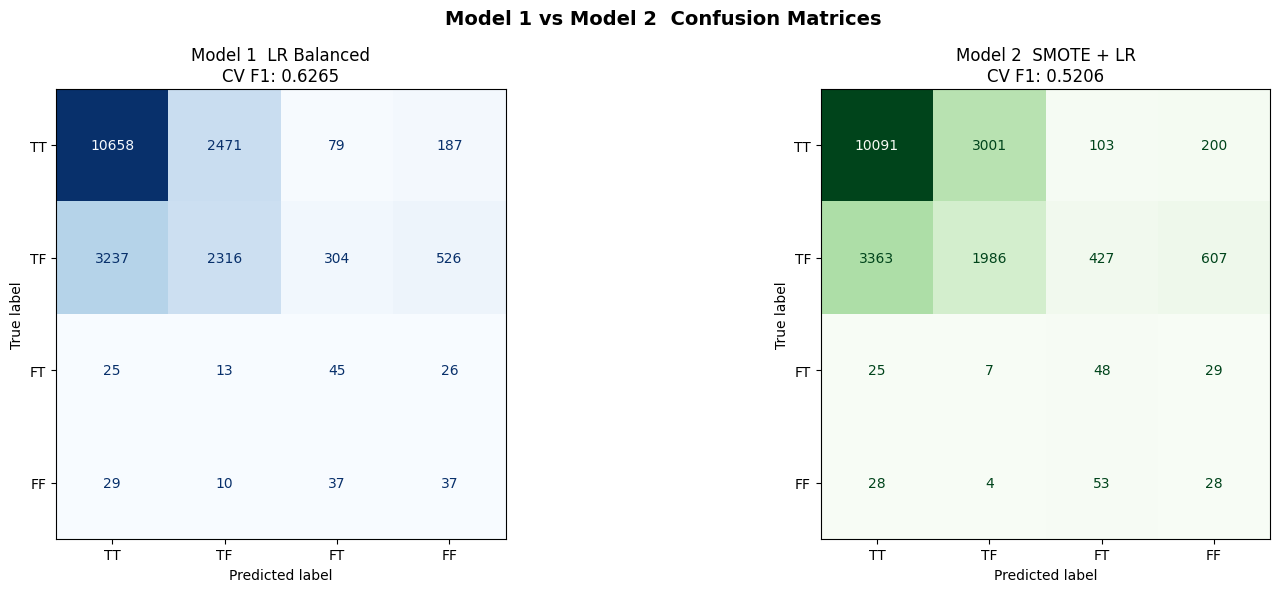

 Comparison chart saved!


In [84]:
# # Training model on the 100k rows SMOTE data
# Future: train on 1 million rows SMOTE data [not yet done!] 

#beautify
print("Training Model 2 on SMOTE balanced data...")
# model 2 training on SMOTE 
model_2_smote_lr.fit(X_train_smote_app, y_train_smote_app)
print(" Done!")


#  testing on unseen 
y_pred_m2 = model_2_smote_lr.predict(X_tst_feature_eg)

#  Classification time!
print("\n Model 2 Test Set Results ")

# based on 4 classes 
print(classification_report(
    # 2 predictions to compare -> 1. SMOTE + LR and 2. LR with balanced weights 
    y_test_4, y_pred_m2,
    target_names = [
        'TT-Legit-Normal',
        'TF-Legit-Suspicious',
        # fruad classification is main high light ad fraud also had bad vs wrose atleast 
        'FT-Fraud-Low',
        'FF-Fraud-High'
    ]
))

# displying confusion matrix side by side of both model 
fig_m1, axes_m2 = plt.subplots(1, 2, figsize=(16, 6))

# LR model 1 CM
cm1 = confusion_matrix(y_test_4, y_pred_m1)
ConfusionMatrixDisplay(cm1, 
    display_labels=['TT','TF','FT','FF']
).plot(ax=axes_m2[0], cmap='Blues', colorbar=False,values_format='d')
axes_m2[0].set_title(f'Model 1  LR Balanced\nCV F1: {cv_scores_m1.mean():.4f}', fontsize=12)

# SMOTE + LR model 2 CM 
cm2 = confusion_matrix(y_test_4, y_pred_m2)
ConfusionMatrixDisplay(cm2,
    display_labels=['TT','TF','FT','FF']
).plot(ax=axes_m2[1], cmap='Greens', colorbar=False, values_format='d')
axes_m2[1].set_title(f'Model 2  SMOTE + LR\nCV F1: {cv_scores_m2.mean():.4f}', fontsize=12)

# title 
plt.suptitle('Model 1 vs Model 2  Confusion Matrices', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# dump to /reports/figures/xxxx
plt.savefig('../reports/figures/model_comparison_confusion.png', dpi=150)
plt.show()
print(" Comparison chart saved!")

## 11. Final comparision between models
Comparison of Model 1 vs Model 2 based on training accuracy, test accuracy, and weighted F1-score. Detection of overfitting through the train-test difference.

In [85]:
#  now lets understand why are the  TF and FF are failing 


# misclassified TF & FF analysis 
x_anlys_copy = X_test.copy()
x_anlys_copy['true_label'] = y_test_4.values

# features I used to create my label distribution 
all_key_features_used = ['amt', 'avg_amt_per_customer', 
                'merchant_risk_30_day', 'merchant_risk_7_day',
                'trans_time_is_night', 'customer_num_trans_1_day']

#info 
print(" Average feature values per class ")
print(x_anlys_copy.groupby('true_label')[all_key_features_used].mean().round(2))


print("\n separable in the classes based on defined features! ")

# printing AVG values for understanding the differences 
for i, j in label_names.items():
    # filter data for current classs
    each_cls_data = x_anlys_copy[x_anlys_copy['true_label'] == i]
    
    print(f"\n  Class {i} ({j}):")
    # avg values of my features 
    print(f"    avg amt          = ${each_cls_data['amt'].mean():.2f}")
    # avg amt per cus
    print(f"    avg merchant_risk= {each_cls_data['merchant_risk_30_day'].mean():.2f}")
    # night fraud very easy detection usage 
    print(f"    night %          = {each_cls_data['trans_time_is_night'].mean()*100:.1f}%")
    print(f"    count            = {len(each_cls_data)}")

 Average feature values per class 
               amt  avg_amt_per_customer  merchant_risk_30_day  \
true_label                                                       
0            43.64                 71.78                 14.48   
1           122.21                 70.65                 19.72   
2           511.44                200.38                 12.61   
3           520.53                189.32                 19.66   

            merchant_risk_7_day  trans_time_is_night  customer_num_trans_1_day  
true_label                                                                      
0                          8.93                 0.29                      2.98  
1                          9.93                 0.30                      3.02  
2                          8.78                 0.31                      3.16  
3                         10.82                 0.27                      3.14  

 separable in the classes based on defined features! 

  Class 0 (TT-Legit-Normal

## 12. Final Summary 

comparing both model's Side by Side based on f1 scores , train & test accuracy 

In [86]:
# for result summary eaise my work 
from sklearn.metrics import accuracy_score, f1_score


# beautify 
print("=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)


#accuracy on train and test for m1 and m2

# eng - > feauture 5 we added 
y_train_pred_m1_lr = model_lr_1.predict(X_tr_feature_eg)
# SMOTE data for m2 we did
y_train_pred_m2_smote = model_2_smote_lr.predict(X_train_smote_app)

# testing same 
m1_train_ac_scr = accuracy_score(y_train_4, y_train_pred_m1_lr)
# smote test ?
m2_train_ac_scr = accuracy_score(y_train_smote_app, y_train_pred_m2_smote)

# accuracy of both 
m1_test_acc_scr  = accuracy_score(y_test_4, y_pred_m1)
m2_test_acc_scr  = accuracy_score(y_test_4, y_pred_m2)

# all ceriticaions :  f1 scores CV etc..
f1_m1_tr  = f1_score(y_train_4, y_train_pred_m1_lr, average='weighted')
# m2 signifance is only less in this model and nothing else 
f1_m2_tr  = f1_score(y_train_smote_app, y_train_pred_m2_smote, average='weighted')

# test f1 score is IMP as unseen data tells us how it works in real world 
f1_m1_tst   = f1_score(y_test_4, y_pred_m1, average='weighted')
f1_m2_tst   = f1_score(y_test_4, y_pred_m2, average='weighted')

# beautify printing info 
# the f1 score for test and train is more IMP than accuracy 
# as the data is imbalanced and accuracy can be misleading, f1 score gives better understanding of the model. 
print(f"""

              MODEL 1  LR (class_weight=balanced)        

  CV Mean F1     : {cv_scores_m1.mean():.4f}                             
  Train Accuracy : {m1_train_ac_scr*100:.2f}%                            
  Test  Accuracy : {m1_test_acc_scr*100:.2f}%              
  Train F1       : {f1_m1_tr:.4f}                             
  Test  F1       : {f1_m1_tst:.4f}                             

              MODEL 2  SMOTE + LR                        

  CV Mean F1     : {cv_scores_m2.mean():.4f}                             
  Train Accuracy : {m2_train_ac_scr*100:.2f}%                            
  Test  Accuracy : {m2_test_acc_scr*100:.2f}%                             
  Train F1       : {f1_m2_tr:.4f}                             
  Test  F1       : {f1_m2_tst:.4f}                             

""")


  FINAL RESULTS SUMMARY


              MODEL 1  LR (class_weight=balanced)        

  CV Mean F1     : 0.6265                             
  Train Accuracy : 66.12%                            
  Test  Accuracy : 65.28%              
  Train F1       : 0.6648                             
  Test  F1       : 0.6555                             

              MODEL 2  SMOTE + LR                        

  CV Mean F1     : 0.5206                             
  Train Accuracy : 51.33%                            
  Test  Accuracy : 60.77%                             
  Train F1       : 0.5016                             
  Test  F1       : 0.6149                             




## 13. Saving Trained model and metadata 
Serializing both models as timestamps named `.joblib` and boarding it to /models metadata to `model_metadata.json`.

In [87]:
import joblib
import json
from datetime import datetime
from sklearn.metrics import f1_score, accuracy_score

# checking directory exist before do all 
os.makedirs('../models', exist_ok=True)

#current timestamp for version 
time_stmp = datetime.now().strftime("%Y%m%d")

# model 1 being saved to /models named as lr_balanced_timestamp.joblib
path_model_1_lr = f'../models/lr_balanced_{time_stmp}.joblib'
joblib.dump(model_lr_1, path_model_1_lr)
print(f" Model 1 saved  {path_model_1_lr}")

#model 2 being saved to /models named as lr_balanced_timestamp.joblib
path_model_2_smote = f'../models/lr_smote_{time_stmp}.joblib'
joblib.dump(model_2_smote_lr, path_model_2_smote)
print(f" Model 2 saved  {path_model_2_smote}")

# metadata straight to JSON for tracking and reproducibility 
mtd = {
    "dataset"        : "Credit Card Fraud Detection  Kaggle",
    "dataset_version": "DVC tracked  data/processed/",
    "training_date"  : time_stmp,
    "train_samples"  : int(X_tr_feature_eg.shape[0]),
    "test_samples"   : int(X_tst_feature_eg.shape[0]),
    "features"       : int(X_tr_feature_eg.shape[1]),
    "classes"        : {
        "0": "TT-Legit-Normal",
        "1": "TF-Legit-Suspicious",
        "2": "FT-Fraud-LowRisk",
        "3": "FF-Fraud-HighRisk"
    },
    "model_1": {
        "name"          : "LogisticRegression",
        "class_weight"  : "balanced",
        "max_iter"      : 1000,
        "cv_f1_mean"    : round(float(cv_scores_m1.mean()), 4),
        "cv_f1_std"     : round(float(cv_scores_m1.std()), 4),
        "train_accuracy": round(accuracy_score(y_train_4, model_lr_1.predict(X_tr_feature_eg)), 4),
        "test_accuracy" : round(accuracy_score(y_test_4, y_pred_m1), 4),
        "test_f1"       : round(f1_score(y_test_4, y_pred_m1, average='weighted'), 4),
        "file"          : path_model_1_lr
    },
    "model_2": {
        "name"          : "LogisticRegression + SMOTE",
        "class_weight"  : "balanced",
        "max_iter"      : 1000,
        "smote_strategy": "auto (equal classes)",
        "cv_f1_mean"    : round(float(cv_scores_m2.mean()), 4),
        "cv_f1_std"     : round(float(cv_scores_m2.std()), 4),
        "train_accuracy": round(accuracy_score(y_train_smote_app, model_2_smote_lr.predict(X_train_smote_app)), 4),
        "test_accuracy" : round(accuracy_score(y_test_4, y_pred_m2), 4),
        "test_f1"       : round(f1_score(y_test_4, y_pred_m2, average='weighted'), 4),
        "file"          : path_model_2_smote
    },
    "reproducibility": {
        "random_seed"    : 42,
        "cv_strategy"    : "StratifiedKFold(n_splits=5)",
        "data_versioning": "DVC (Google Drive remote)",
        "environment"    : "requirements.txt pinned versions"
    }
}

# where to save the metadata to /models
to_go_mtd_path = '../models/model_metadata.json'
with open(to_go_mtd_path, 'w') as f:
    json.dump(mtd, f, indent=2)
print(f" Metadata saved  {to_go_mtd_path}")

 Model 1 saved  ../models/lr_balanced_20260507.joblib
 Model 2 saved  ../models/lr_smote_20260507.joblib
 Metadata saved  ../models/model_metadata.json


In [88]:
## Explanation and Thoughts 

print(" Why SMOTE Was Used ")
print("""
  SMOTE (Synthetic Minority Oversampling Technique) is used to
  compare with the class_weight='balanced' approach. Given that
  there are approx 880 ish fraud samples in a dataset of 80,000 train (1.1%),
  the model usually  ignores the rare fraud classes. SMOTE,
  therefore, generates additional synthetic (fake) fraud samples,
  this will provide more examples for the model to train on.
""")

print(" SMOTE Result ")
print("""
  SMOTE did help to improve the CV F1 score but did NOT improve the train & test
  set performance. we know that SMOTE-generated samples may
  not represent the full clarity of actual fraud samples,
  mainly when the size of the original fraud samples is just 
  limited (887 rows).  
  Conclusion: class_weight='balanced' (Model 1) generalizes better.
""")

# overfitting is checked to model generalization and test performance on test 
print(" Overfitting Check ")
m1_train_ac_scr = accuracy_score(y_train_4, model_lr_1.predict(X_tr_feature_eg))
m2_train_ac_scr = accuracy_score(y_train_smote_app, model_2_smote_lr.predict(X_train_smote_app))
m1_test_acc_scr  = accuracy_score(y_test_4, y_pred_m1)
m2_test_acc_scr  = accuracy_score(y_test_4, y_pred_m2)

# the diff is claculated 
m1_gap = abs(m1_train_ac_scr - m1_test_acc_scr) * 100
m2_gap = abs(m2_train_ac_scr - m2_test_acc_scr) * 100

# beautify printing info 
print(f"  Model 1  Train: {m1_train_ac_scr*100:.1f}%  Test: {m1_test_acc_scr*100:.1f}%  Gap: {m1_gap:.1f}%",
      " No overfitting" if m1_gap < 5 else " Possible overfitting")

print(f"  Model 2  Train: {m2_train_ac_scr*100:.1f}%  Test: {m2_test_acc_scr*100:.1f}%  Gap: {m2_gap:.1f}%",
      " No overfitting" if m2_gap < 5 else " gap is due to SMOTE synthetic data")

# why its not just the  overfitting as it is intended to go like that 
print("""
    Note about the Model 2 gap: Model 2 is trained using balanced data via SMOTE technique
    (215,736 rows) whereas tested using actual imbalanced data (20,000 rows).
    This discrepancy is because of the distribution disparity of training vs. testing data set,
    not overfitting.
""")

 Why SMOTE Was Used 

  SMOTE (Synthetic Minority Oversampling Technique) is used to
  compare with the class_weight='balanced' approach. Given that
  there are approx 880 ish fraud samples in a dataset of 80,000 train (1.1%),
  the model usually  ignores the rare fraud classes. SMOTE,
  therefore, generates additional synthetic (fake) fraud samples,
  this will provide more examples for the model to train on.

 SMOTE Result 

  SMOTE did help to improve the CV F1 score but did NOT improve the train & test
  set performance. we know that SMOTE-generated samples may
  not represent the full clarity of actual fraud samples,
  mainly when the size of the original fraud samples is just 
  limited (887 rows).  
  Conclusion: class_weight='balanced' (Model 1) generalizes better.

 Overfitting Check 
  Model 1  Train: 66.1%  Test: 65.3%  Gap: 0.8%  No overfitting
  Model 2  Train: 51.3%  Test: 60.8%  Gap: 9.4%  gap is due to SMOTE synthetic data

    Note about the Model 2 gap: Model 2 is tra